In [29]:
import csv
import time
import struct
import threading
from dataclasses import dataclass, asdict
from pathlib import Path
from queue import Queue, Empty

import serial

# Reuse your uploaded protocol helpers
from protocol import (
    build_frame,
    PROTOCOL_VER,
    FLAG_DATA,
    ID_PC,
    ID_DRONE,
)

In [30]:
@dataclass
class TestConfig:
    # Serial ports
    arduino_port: str = "COM7"      # change
    arduino_baud: int = 115200

    drone_port: str = "COM5"        # change
    drone_baud: int = 9600           # drone UART baud rate

    # EDF sweep
    start_power: int = 0
    end_power: int = 100
    power_step: int = 5
    dwell_time_s: float = 3.0        # time spent at each power step

    # Moving average over N raw samples
    moving_avg_window_samples: int = 10

    # Servo angles (real angles in degrees)
    # Encoded value sent is angle + 90 (max 37deg)
    x_plus_angle_deg: int = 0
    x_minus_angle_deg: int = 0
    y_plus_angle_deg: int = 0
    y_minus_angle_deg: int = 0

    # Load-cell options
    use_second_loadcell: bool = True

    # Logging
    output_csv: str = "edf_test_log.csv"

    # Optional settling times
    pre_test_idle_s: float = 2.0
    post_test_idle_s: float = 2.0

cfg = TestConfig()
cfg


TestConfig(arduino_port='COM7', arduino_baud=115200, drone_port='COM5', drone_baud=9600, start_power=0, end_power=100, power_step=5, dwell_time_s=3.0, moving_avg_window_samples=10, x_plus_angle_deg=0, x_minus_angle_deg=0, y_plus_angle_deg=0, y_minus_angle_deg=0, use_second_loadcell=True, output_csv='edf_test_log.csv', pre_test_idle_s=2.0, post_test_idle_s=2.0)

In [31]:
OPT_CAL_PARAM = 0x60

def encode_servo_angle(angle_deg: int) -> int:
    """
    Drone expects stored_angle = real_angle + 90
    Example:
      -10 deg -> 80
        0 deg -> 90
       10 deg -> 100
    """
    encoded = angle_deg + 90
    if encoded < -128 or encoded > 127:
        raise ValueError(f"Encoded servo value out of int8 range: {encoded}")
    return encoded

def build_calib_frame(
    edf_pwr_percent: int,
    x_plus_angle_deg: int = 0,
    x_minus_angle_deg: int = 0,
    y_plus_angle_deg: int = 0,
    y_minus_angle_deg: int = 0,
) -> bytes:
    if not (0 <= edf_pwr_percent <= 100):
        raise ValueError("edf_pwr_percent must be in range 0..100")

    payload = struct.pack(
        "<bbbbb",
        edf_pwr_percent,
        encode_servo_angle(x_plus_angle_deg),
        encode_servo_angle(x_minus_angle_deg),
        encode_servo_angle(y_plus_angle_deg),
        encode_servo_angle(y_minus_angle_deg),
    )

    frame = build_frame(
        version=PROTOCOL_VER,
        flags=FLAG_DATA,
        src=ID_PC,
        dst=ID_DRONE,
        opcode=OPT_CAL_PARAM,
        payload=payload,
    )
    return frame

In [32]:
@dataclass
class SensorSample:
    pc_time_s: float
    arduino_time_us: int
    load1: float
    load2: float

class ArduinoReader(threading.Thread):
    def __init__(self, ser: serial.Serial, out_queue: Queue):
        super().__init__(daemon=True)
        self.ser = ser
        self.out_queue = out_queue
        self._stop = threading.Event()

    def stop(self):
        self._stop.set()

    def run(self):
        while not self._stop.is_set():
            try:
                line = self.ser.readline().decode("utf-8", errors="ignore").strip()
                if not line or line.startswith("#"):
                    continue

                parts = line.split(",")
                if len(parts) < 3:
                    continue

                arduino_time_us = int(parts[0])
                load1 = float(parts[1])
                load2 = float(parts[2])

                sample = SensorSample(
                    pc_time_s=time.time(),
                    arduino_time_us=arduino_time_us,
                    load1=load1,
                    load2=load2,
                )
                self.out_queue.put(sample)

            except Exception:
                # keep running even if one line is corrupted
                continue

In [33]:
from collections import deque


def build_power_sequence(start_power: int, end_power: int, power_step: int) -> list[int]:
    if power_step <= 0:
        raise ValueError("power_step must be > 0")
    if start_power > end_power:
        raise ValueError("start_power must be <= end_power")

    power_values_up = list(range(start_power, end_power + 1, power_step))
    if power_values_up[-1] != end_power:
        power_values_up.append(end_power)

    # Return back down to the start value.
    # Example: 0,10,...,100,90,...,0
    power_values_down = list(range(end_power - power_step, start_power - 1, -power_step))
    if not power_values_down or power_values_down[-1] != start_power:
        power_values_down.append(start_power)

    return power_values_up + power_values_down


def run_edf_test(cfg: TestConfig):

    power_values = build_power_sequence(cfg.start_power, cfg.end_power, cfg.power_step)
    output_path = Path(cfg.output_csv)

    sensor_queue = Queue()
    rows = []

    load1_window = deque(maxlen=cfg.moving_avg_window_samples)
    load2_window = deque(maxlen=cfg.moving_avg_window_samples)

    print("Opening serial ports...")

    arduino_ser = serial.Serial(cfg.arduino_port, cfg.arduino_baud, timeout=0.2)
    drone_ser = serial.Serial(cfg.drone_port, cfg.drone_baud, timeout=0.2)

    time.sleep(2)  # allow ports to stabilize

    reader = ArduinoReader(arduino_ser, sensor_queue)
    reader.start()

    current_power = cfg.start_power
    current_step_index = -1
    current_direction = "idle"
    last_step_change_pc_s = time.time()
    transition_flag = 0
    last_frame_hex = ""

    def drain_queue():
        nonlocal transition_flag
        while True:
            try:
                sample = sensor_queue.get_nowait()
            except Empty:
                break

            raw_load1 = sample.load1
            raw_load2 = sample.load2 if cfg.use_second_loadcell else ""

            load1_window.append(raw_load1)
            avg_load1 = sum(load1_window) / len(load1_window)

            if cfg.use_second_loadcell:
                load2_window.append(sample.load2)
                avg_load2 = sum(load2_window) / len(load2_window)
            else:
                avg_load2 = ""

            row = {
                "pc_time_s": sample.pc_time_s,
                "arduino_time_us": sample.arduino_time_us,
                "step_index": current_step_index,
                "step_direction": current_direction,
                "edf_power_percent": current_power,
                "load1_raw": raw_load1,
                "load2_raw": raw_load2,
                "load1_moving_avg": avg_load1,
                "load2_moving_avg": avg_load2,
                "moving_avg_window_samples": cfg.moving_avg_window_samples,
                "transition_flag": transition_flag,
                "time_since_step_s": sample.pc_time_s - last_step_change_pc_s,
                "sent_frame_hex": last_frame_hex,
            }

            rows.append(row)
            transition_flag = 0

    try:

        # ---------------------------
        # TARE BEFORE TEST
        # ---------------------------

        # print("Sending TARE command to Arduino...")

        # arduino_ser.reset_input_buffer()
        # arduino_ser.write(b"T\n")

        # while True:
        #     line = arduino_ser.readline().decode(errors="ignore").strip()

        #     if line:
        #         print("Arduino:", line)

        #     if "TARE_DONE" in line:
        #         break

        # print("Tare completed")

        print("Waiting for system to stabilize...")
        time.sleep(cfg.pre_test_idle_s)

        # ---------------------------
        # START POWER SWEEP
        # ---------------------------

        print("Starting EDF sweep")
        print("Power sequence:", power_values)

        for step_idx, pwr in enumerate(power_values):
            if step_idx == 0:
                direction = "up"
            else:
                prev_pwr = power_values[step_idx - 1]
                if pwr > prev_pwr:
                    direction = "up"
                elif pwr < prev_pwr:
                    direction = "down"
                else:
                    direction = "hold"

            frame = build_calib_frame(
                edf_pwr_percent=pwr,
                x_plus_angle_deg=cfg.x_plus_angle_deg,
                x_minus_angle_deg=cfg.x_minus_angle_deg,
                y_plus_angle_deg=cfg.y_plus_angle_deg,
                y_minus_angle_deg=cfg.y_minus_angle_deg,
            )

            drone_ser.write(frame)
            drone_ser.flush()

            current_power = pwr
            current_step_index = step_idx
            current_direction = direction
            last_step_change_pc_s = time.time()
            transition_flag = 1
            last_frame_hex = frame.hex(" ")

            print(
                f"Step {step_idx:03d} | direction={direction:>4s} | EDF={pwr:3d}% | frame={last_frame_hex}"
            )

            dwell_start = time.time()
            while time.time() - dwell_start < cfg.dwell_time_s:
                drain_queue()
                time.sleep(0.002)

        # Keep collecting a little after the last step if needed
        print("Waiting after final step...")
        time.sleep(cfg.post_test_idle_s)
        drain_queue()

    finally:

        reader.stop()
        time.sleep(0.2)
        drain_queue()

        try:
            arduino_ser.close()
        except Exception:
            pass

        try:
            drone_ser.close()
        except Exception:
            pass

    fieldnames = [
        "pc_time_s",
        "arduino_time_us",
        "step_index",
        "step_direction",
        "edf_power_percent",
        "load1_raw",
        "load2_raw",
        "load1_moving_avg",
        "load2_moving_avg",
        "moving_avg_window_samples",
        "transition_flag",
        "time_since_step_s",
        "sent_frame_hex",
    ]

    with open(output_path, "w", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(rows)

    print(f"Saved {len(rows)} rows to {output_path}")

    return rows


In [ ]:
cfg = TestConfig(
    arduino_port="COM7",     # change to your Arduino port
    drone_port="COM5",       # change to your drone/UART port
    drone_baud=9600,
    start_power=0,
    end_power=100,
    power_step=5,
    dwell_time_s=3.0,
    moving_avg_window_samples=10,
    output_csv="Meritve/edf_motor_characterization.csv",
    use_second_loadcell=True,
)

rows = run_edf_test(cfg) # uncomment tare


Opening serial ports...
Waiting for system to stabilize...
Starting EDF sweep
Power sequence: [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 90, 80, 70, 60, 50, 40, 30, 20, 10, 0]
Step 000 | direction=  up | EDF=  0% | frame=aa 0d 01 05 01 20 60 05 00 5a 5a 5a 5a 7a b6
Step 001 | direction=  up | EDF= 10% | frame=aa 0d 01 05 01 20 60 05 0a 5a 5a 5a 5a e2 b7
Step 002 | direction=  up | EDF= 20% | frame=aa 0d 01 05 01 20 60 05 14 5a 5a 5a 5a 4a b5
Step 003 | direction=  up | EDF= 30% | frame=aa 0d 01 05 01 20 60 05 1e 5a 5a 5a 5a d2 b4
Step 004 | direction=  up | EDF= 40% | frame=aa 0d 01 05 01 20 60 05 28 5a 5a 5a 5a 1a b0
Step 005 | direction=  up | EDF= 50% | frame=aa 0d 01 05 01 20 60 05 32 5a 5a 5a 5a 43 72
Step 006 | direction=  up | EDF= 60% | frame=aa 0d 01 05 01 20 60 05 3c 5a 5a 5a 5a 2a b3
Step 007 | direction=  up | EDF= 70% | frame=aa 0d 01 05 01 20 60 05 46 5a 5a 5a 5a f3 79
Step 008 | direction=  up | EDF= 80% | frame=aa 0d 01 05 01 20 60 05 50 5a 5a 5a 5a ba ba
Step 009 | d

In [ ]:
import pandas as pd

csv_file = "Meritve/edf_motor_characterization.csv"

df = pd.read_csv(csv_file)

# ==========================
# CALIBRATION CONSTANTS
# ==========================

counts_per_kg_loadcell1 = 220000
counts_per_kg_loadcell2 = 220000

g = 9.80665

# ==========================
# Convert moving-average raw counts -> Newtons
# ==========================

df["force1_N"] = (df["load1_moving_avg"] / counts_per_kg_loadcell1) * g

if "load2_moving_avg" in df.columns:
    df["force2_N"] = pd.to_numeric(df["load2_moving_avg"], errors="coerce")
    df["force2_N"] = (df["force2_N"] / counts_per_kg_loadcell2) * g
else:
    df["force2_N"] = None

df["force_total_N"] = df["force1_N"] + df["force2_N"].fillna(0)

print(df.head())

out = "Meritve/edf_motor_characterization_newtons.csv"
df.to_csv(out, index=False)

print("Saved converted data:", out)


Empty DataFrame
Columns: [pc_time_s, arduino_time_us, step_index, step_direction, edf_power_percent, load1_raw, load2_raw, load1_moving_avg, load2_moving_avg, moving_avg_window_samples, transition_flag, time_since_step_s, sent_frame_hex, force1_N, force2_N, force_total_N]
Index: []
Saved converted data: edf_motor_characterization_newtons.csv


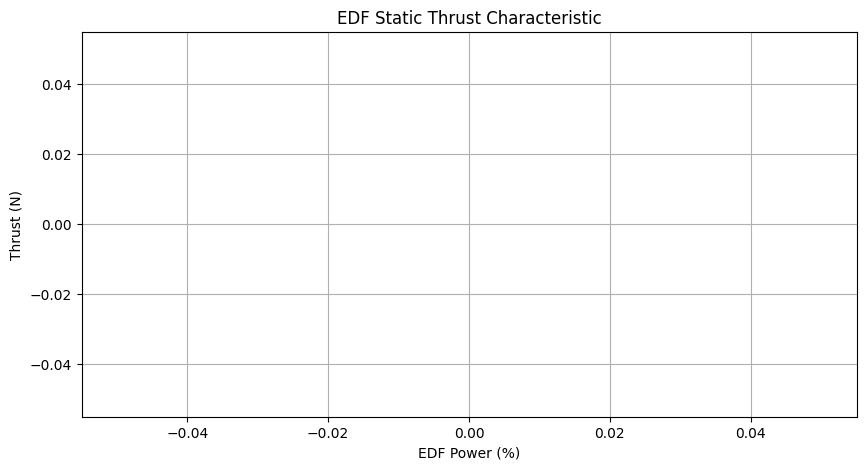

In [36]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(df["edf_power_percent"], df["force_total_N"], '.', alpha=0.4)
plt.xlabel("EDF Power (%)")
plt.ylabel("Thrust (N)")
plt.title("EDF Static Thrust Characteristic")
plt.grid()
plt.show()
